In [2]:
import cv2
import os

def register_user():
    # Ask for user details
    user_name = input("Enter your name: ")
    
    # Create a folder for the user
    user_folder = f"fingerprint_dataset/{user_name}"
    os.makedirs(user_folder, exist_ok=True)
    
    # Open the camera to capture fingerprint
    cap = cv2.VideoCapture(0)
    print("Press 's' to save the fingerprint image or 'q' to quit")
    
    count = 1
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to capture image.")
            break
        
        # Show the live feed
        cv2.imshow("Fingerprint Capture", frame)
        
        # Wait for user input
        key = cv2.waitKey(1) & 0xFF
        if key == ord('s'):  # Save the image
            file_path = f"{user_folder}/fingerprint_{count}.jpg"
            cv2.imwrite(file_path, frame)
            print(f"Fingerprint image saved as {file_path}")
            count += 1
        elif key == ord('q'):  # Quit
            print("Exiting fingerprint registration.")
            break

    cap.release()
    cv2.destroyAllWindows()
    
# Register a user
register_user()


Press 's' to save the fingerprint image or 'q' to quit
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_1.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_2.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_3.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_4.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_5.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_6.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_7.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_8.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_9.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_10.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_11.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_12.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_13.jpg
Finge

In [ ]:
#FingVGGNet: A combination of "Fingerprint" and "VGGNet," which indicates the specialized model for fingerprint recognition based on the VGG architecture.

Epoch 1/10
3/3 [==============================] - 32s 11s/step - loss: 2.0193 - accuracy: 0.4167 - val_loss: 0.9009 - val_accuracy: 0.8889
Epoch 2/10
3/3 [==============================] - 13s 4s/step - loss: 2.3311 - accuracy: 0.3333 - val_loss: 1.0199 - val_accuracy: 0.4444
Epoch 3/10
3/3 [==============================] - 23s 9s/step - loss: 2.1736 - accuracy: 0.4167 - val_loss: 0.3177 - val_accuracy: 1.0000
Epoch 4/10
3/3 [==============================] - 23s 9s/step - loss: 1.5359 - accuracy: 0.5000 - val_loss: 0.2349 - val_accuracy: 1.0000
Epoch 5/10
3/3 [==============================] - 22s 9s/step - loss: 1.6480 - accuracy: 0.5000 - val_loss: 0.1494 - val_accuracy: 0.8889
Epoch 6/10
3/3 [==============================] - 23s 9s/step - loss: 1.2202 - accuracy: 0.6389 - val_loss: 0.1284 - val_accuracy: 0.8889
Epoch 7/10
3/3 [==============================] - 23s 9s/step - loss: 0.9917 - accuracy: 0.6944 - val_loss: 0.0477 - val_accuracy: 1.0000
Epoch 8/10
3/3 [=================

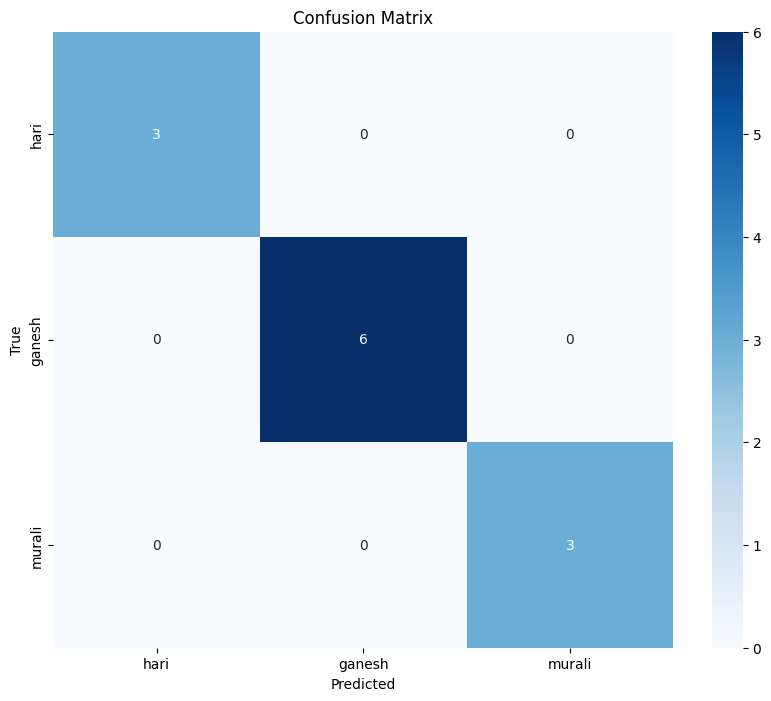

1/1 [==============================] - 0s 301ms/step
Predicted User: murali


In [2]:
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import VGG19, ResNet101
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Concatenate
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

IMG_SIZE = 224  # Image dimensions for VGG19 and ResNet101

def load_images_and_labels(dataset_path):
    images = []
    labels = []
    label_map = {}  # Map user folders to numeric labels
    label_index = 0

    for user_folder in os.listdir(dataset_path):
        user_path = os.path.join(dataset_path, user_folder)
        if os.path.isdir(user_path):
            # Assign a numeric label to each user
            if user_folder not in label_map:
                label_map[user_folder] = label_index
                label_index += 1

            for file in os.listdir(user_path):
                file_path = os.path.join(user_path, file)
                # Read, resize, and preprocess the image
                image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
                image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))      # Resize to 224x224
                image = np.stack((image,)*3, axis=-1)                # Convert to 3-channel (RGB)
                images.append(image)
                labels.append(label_map[user_folder])

    images = np.array(images) / 255.0  # Normalize pixel values
    labels = np.array(labels)
    return images, labels, label_map

# Load the dataset
dataset_path = "fingerprint_dataset"
images, labels, label_map = load_images_and_labels(dataset_path)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)
y_train = to_categorical(y_train, num_classes=len(label_map))
y_test = to_categorical(y_test, num_classes=len(label_map))

def build_hybrid_model(num_classes):
    # Load the VGG19 model without the top layer
    vgg19_base = VGG19(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    # Load the ResNet101 model without the top layer
    resnet101_base = ResNet101(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    
    # Freeze the base model layers
    for layer in vgg19_base.layers:
        layer.trainable = False
    for layer in resnet101_base.layers:
        layer.trainable = False
    
    # Extract features from both VGG19 and ResNet101
    vgg19_out = Flatten()(vgg19_base.output)
    resnet101_out = Flatten()(resnet101_base.output)
    
    # Concatenate the features from both models
    merged = Concatenate()([vgg19_out, resnet101_out])
    
    # Add custom layers for fingerprint classification
    x = Dense(512, activation='relu')(merged)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)
    
    # Create the hybrid model
    model = Model(inputs=[vgg19_base.input, resnet101_base.input], outputs=output)
    return model

# Build the model
num_classes = len(label_map)  # Number of users
model = build_hybrid_model(num_classes)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Add callbacks
checkpoint = ModelCheckpoint("hybrid_fingerprint_model.h5", save_best_only=True, monitor='val_loss', mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    [X_train, X_train], y_train,  # Input both VGG19 and ResNet101 models with the same images
    validation_split=0.2,
    epochs=10,
    batch_size=16,
    callbacks=[checkpoint, early_stopping]
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate([X_test, X_test], y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Predictions
y_pred = model.predict([X_test, X_test])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=label_map.keys()))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

def predict_user(image_path, model, label_map):
    # Preprocess the input image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = np.stack((image,)*3, axis=-1)  # Convert to 3 channels
    image = image / 255.0  # Normalize
    image = np.expand_dims(image, axis=0)  # Add batch dimension

    # Predict the class using the hybrid model
    prediction = model.predict([image, image])  # Input both VGG19 and ResNet101 models with the same image
    predicted_label = np.argmax(prediction)
    
    # Map the numeric label back to the user name
    user_name = {v: k for k, v in label_map.items()}[predicted_label]
    return user_name

# Test prediction
test_image_path = "tow.jpg"  # Path to the new fingerprint image
predicted_user = predict_user(test_image_path, model, label_map)
print(f"Predicted User: {predicted_user}")
